# Cox-Ross-Rubinstein Model: Methodological Note on Option Pricing

## Introduction

The Cox-Ross-Rubinstein (CRR) binomial model is a discrete-time framework for pricing derivatives, particularly options, on underlying assets whose prices evolve through a multiplicative binomial tree. Introduced by Cox, Ross, and Rubinstein in 1979, this model provides both a practical computational method and a bridge between discrete and continuous-time finance theory.

## Model Framework

### Binomial Price Evolution

At each time step $\Delta t$, the underlying asset price $S$ can move to one of two states:

- **Up move**: $S \to uS$ with probability $p$
- **Down move**: $S \to dS$ with probability $1-p$

where $u > 1$ and $0 < d < 1$ are the up and down multiplicative factors.

### Parameter Specification

The CRR model calibrates these parameters to match the continuous Black-Scholes dynamics:

$$u = e^{\sigma\sqrt{\Delta t}}$$

$$d = e^{-\sigma\sqrt{\Delta t}} = \frac{1}{u}$$

$$p = \frac{e^{r\Delta t} - d}{u - d}$$

where:
- $\sigma$ is the annualized volatility
- $r$ is the risk-free rate
- $\Delta t = T/N$ is the time step size (total maturity $T$ divided into $N$ steps)

The risk-neutral probability $p$ ensures no arbitrage and matches the expected return to the risk-free rate.

## Pricing Algorithm

### Backward Induction

Option valuation proceeds via backward induction through the binomial tree:

1. **Terminal payoff**: At maturity $T$, compute the option payoff at each terminal node.

2. **Recursive valuation**: At each earlier node and time step $t_i$, the option value is:
    $$V(S, t_i) = e^{-r\Delta t}\left[p \cdot V(uS, t_{i+1}) + (1-p) \cdot V(dS, t_{i+1})\right]$$

3. **Continuation**: Continue backward until reaching the initial node at $t=0$.

### Boundary Conditions

- **European options**: Exercise occurs only at maturity.
- **American options**: At each node, compare the intrinsic value with the continuation value, and take the maximum.

## Convergence Properties

### Convergence to Black-Scholes

As the number of steps $N \to \infty$ (and $\Delta t \to 0$), the binomial model converges to the continuous Black-Scholes formula. This convergence is guaranteed provided:

- The parameters $u$ and $d$ scale with $\sqrt{\Delta t}$
- The risk-neutral probability $p$ approaches $0.5$ as volatility and interest rates are held fixed

### Rate of Convergence

For European options, the error decreases approximately as $O(1/N)$. For American options, convergence is typically slower due to discrete exercise decisions.

## Advantages

- **Intuitive**: Easy to understand and implement; provides economic intuition via the tree structure.
- **Flexibility**: Naturally handles American and exotic options with path-dependent features.
- **Transparency**: The tree shows all possible price paths and decision nodes explicitly.
- **Calibration**: Parameters have direct interpretation in terms of volatility and risk-free rate.

## Limitations

- **Computational cost**: For $N$ steps and many options, storage and computation grow with $N^2$ in a recombinant tree.
- **Discrete approximation**: Volatility smile and skew cannot be modeled directly without adjusting parameters over time or across strikes.
- **Oscillation**: Numerical oscillations in convergence can occur for certain parameter combinations.
- **Convergence speed**: Slower than some other methods (e.g., PDE solvers) for plain-vanilla European options.

## Practical Implementation

### Recombinant vs. Non-Recombinant Trees

- **Recombinant**: After $n$ up moves and $m$ down moves, the price is $S_0 u^n d^m$, independent of path order. This reduces nodes from $2^N$ to $(N+1)(N+2)/2$.
- **Non-recombinant**: Used when state-dependent parameters or dividends are needed; requires more nodes and memory.

### Dividend Handling

For dividend-paying assets:
- **Continuous dividends**: Adjust the risk-neutral probability to account for dividend yield $q$:
  $$p = \frac{e^{(r-q)\Delta t} - d}{u - d}$$
- **Discrete dividends**: Subtract known dividend amounts from the stock price at ex-dividend dates.

## Numerical Considerations

1. **Number of steps**: Choose $N$ large enough for acceptable accuracy but manageable computation. $N = 100$ to $500$ is typical for simple options.

2. **Stability**: Ensure $0 < p < 1$ to avoid negative probabilities, which violates risk-neutral assumptions.

3. **Early exercise**: For American options, check at each node whether early exercise is optimal.

## Extensions

- **Multi-dimensional binomial**: Model correlated assets for basket or spread options.
- **Time-varying parameters**: Allow volatility or interest rates to depend on time or state.
- **Jump-diffusion binomial**: Incorporate jump risks in addition to diffusion.

## Summary

The Cox-Ross-Rubinstein binomial model is a foundational discrete-time framework for option pricing. It offers simplicity, flexibility, and intuitive appeal, making it invaluable for educational purposes and practical applications involving exotic or early-exercise features. While convergence to the Black-Scholes model is guaranteed, practitioners must balance accuracy and computational efficiency when choosing the number of tree steps. The CRR approach remains central to derivatives valuation and serves as a benchmark for understanding continuous-time models.

--- Dati Sottostante (AAPL) ---
Prezzo Sottostante (S0): $ 311.23
Volatilità stimata (sigma): 22.28%

--- Dati Opzione ---
Strike (K): $ 317.45
Scadenza (T): 0.25 anni
Prezzo dell'opzione Call calcolato: $ 12.08


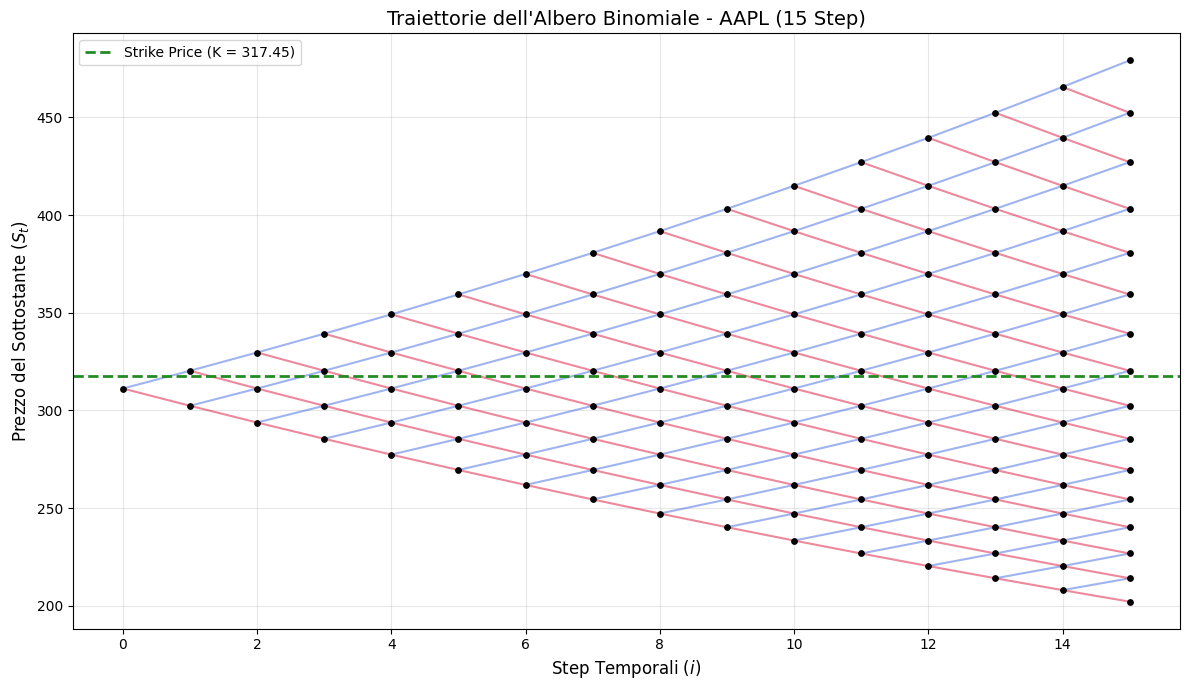

In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 1. Download Dati di mercato
ticker = 'AAPL'
df = yf.download(ticker, period='1y', interval='1d', progress=False).dropna()

# Estrazione robusta del prezzo (gestisce sia DataFrame standard che MultiIndex di yfinance)
if isinstance(df.columns, pd.MultiIndex):
    close = df['Close', ticker]
else:
    close = df['Close']

S0 = close.iloc[-1]
returns = np.log(close / close.shift(1)).dropna()
sigma = returns.std() * np.sqrt(252)

# 2. Parametri dell'Opzione
r = 0.03
T = 0.25
K = S0 * 1.02

# NOTA: Usiamo N=15 per poter visualizzare chiaramente le traiettorie nel grafico. 
# Per un pricing molto accurato, alza questo valore (es. 100 o 500), ma disabilita il plot.
N = 15  

# 3. Funzione Albero Binomiale (Pricer e Generatore Traiettorie)
def binomial_tree(S0, K, T, r, sigma, N, is_call=True, is_american=False):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Inizializza l'albero dei prezzi del sottostante
    # Riga (j): numero di "up moves", Colonna (i): step temporale
    S_tree = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            S_tree[j, i] = S0 * (u ** j) * (d ** (i - j))

    # Inizializza l'albero dei valori dell'opzione
    V_tree = np.zeros((N + 1, N + 1))

    # Calcola il Payoff a scadenza (ultimo step temporale N)
    for j in range(N + 1):
        if is_call:
            V_tree[j, N] = max(0, S_tree[j, N] - K)
        else:
            V_tree[j, N] = max(0, K - S_tree[j, N])

    # Backward induction (procede a ritroso dalla scadenza verso oggi)
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            # Valore atteso neutrale al rischio scontato
            V_tree[j, i] = discount * (p * V_tree[j + 1, i + 1] + (1 - p) * V_tree[j, i + 1])

            # Condizione di esercizio anticipato (solo per opzioni Americane)
            if is_american:
                intrinsic_val = S_tree[j, i] - K if is_call else K - S_tree[j, i]
                V_tree[j, i] = max(V_tree[j, i], intrinsic_val)

    return V_tree[0, 0], S_tree

# 4. Esecuzione del Calcolo
option_price, S_tree = binomial_tree(S0, K, T, r, sigma, N, is_call=True, is_american=False)

# Stampa i Risultati
print(f"--- Dati Sottostante ({ticker}) ---")
print(f"Prezzo Sottostante (S0): $ {S0:.2f}")
print(f"Volatilità stimata (sigma): {sigma:.2%}")
print(f"\n--- Dati Opzione ---")
print(f"Strike (K): $ {K:.2f}")
print(f"Scadenza (T): {T} anni")
print(f"Prezzo dell'opzione Call calcolato: $ {option_price:.2f}")

# 5. Plot delle Traiettorie (Albero Binomiale)
plt.figure(figsize=(12, 7))

# Disegna le linee (traiettorie) e i nodi
for i in range(N):
    for j in range(i + 1):
        # Linea 'Up' (blu)
        plt.plot([i, i + 1], [S_tree[j, i], S_tree[j + 1, i + 1]], color='royalblue', alpha=0.5, linewidth=1.5)
        # Linea 'Down' (rossa)
        plt.plot([i, i + 1], [S_tree[j, i], S_tree[j, i + 1]], color='crimson', alpha=0.5, linewidth=1.5)
        # Disegna il nodo attuale
        plt.scatter(i, S_tree[j, i], color='black', s=15, zorder=3)

# Disegna i nodi finali a scadenza
for j in range(N + 1):
    plt.scatter(N, S_tree[j, N], color='black', s=15, zorder=3)

# Formattazione del Grafico
plt.axhline(K, color='forestgreen', linestyle='--', linewidth=2, label=f'Strike Price (K = {K:.2f})')
plt.title(f'Traiettorie dell\'Albero Binomiale - {ticker} ({N} Step)', fontsize=14)
plt.xlabel('Step Temporali ($i$)', fontsize=12)
plt.ylabel('Prezzo del Sottostante ($S_t$)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()